<a href="https://colab.research.google.com/github/maurocollin/bigdata-saude-niteroi/blob/main/Trabalho_ESCOLHER_PRONTO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ==============================================================================
# BLOCO 1: IMPORTAÇÃO DE BIBLIOTECAS E CARREGAMENTO DE DADOS (GITHUB)
# ==============================================================================

import pandas as pd
import numpy as np
import unicodedata
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression

# Configuração visual
sns.set_theme(style="whitegrid")

# Endereço base do seu repositório no GitHub (versão RAW para leitura direta)
base_url = "https://raw.githubusercontent.com/maurocollin/bigdata-saude-niteroi/main/"

print("Carregando arquivos diretamente do GitHub...")

try:
    # Leitura das bases com nomes ajustados (sem acentos)
    df_pop = pd.read_csv(f"{base_url}Agregados_por_bairros_basico_BR.csv", sep=';', encoding='latin1', on_bad_lines='skip')
    df_ubs = pd.read_csv(f"{base_url}Unidades_Basicas_de_Saude_UBS.csv", encoding='utf-8')
    df_hosp = pd.read_csv(f"{base_url}Hospitais.csv", encoding='utf-8')
    df_poli = pd.read_csv(f"{base_url}Policlinicas.csv", encoding='utf-8')
    df_leitos = pd.read_csv(f"{base_url}CNES_Leitos_Niteroi.csv", encoding='utf-8')

    print("✅ Todos os arquivos foram carregados com sucesso!")
except Exception as e:
    print(f"❌ Erro ao carregar arquivos: {e}")

# Função essencial para padronização
def normalizar_bairro(nome):
    if pd.isna(nome): return ''
    nome = str(nome).upper().strip()
    return ''.join(c for c in unicodedata.normalize('NFD', nome) if unicodedata.category(c) != 'Mn')

Carregando arquivos diretamente do GitHub...
✅ Todos os arquivos foram carregados com sucesso!


In [11]:
# ==============================================================================
# BLOCO 2: PADRONIZAÇÃO E CONSOLIDAÇÃO DAS UNIDADES DE SAÚDE (ATUALIZADO)
# ==============================================================================

print("Iniciando a padronização das unidades de saúde...")

# 1. Padronizar a coluna 'Bairro' em todos os DataFrames de saúde
df_hosp['BAIRRO_NORM'] = df_hosp['tx_bairro'].apply(normalizar_bairro)
df_poli['BAIRRO_NORM'] = df_poli['bairro'].apply(normalizar_bairro)
df_ubs['BAIRRO_NORM'] = df_ubs['bairro'].apply(normalizar_bairro)

# ------------------------------------------------------------------------------
# 2. Nova Função de Classificação (Regras de Negócio e Mineração de Texto)
# ------------------------------------------------------------------------------
def categorizar_gestao(nome):
    nome = str(nome).upper()

    # Palavras-chave que indicam gestão pública
    palavras_publicas = ['MUNICIPAL', 'ESTADUAL', 'FEDERAL', 'UNIVERSITÁRIO', 'POLÍCIA MILITAR']

    # Exceções (Hospitais que não têm as palavras acima, mas são públicos em Niterói)
    excecoes_publicas = [
        'HOSPITAL PSIQUIÁTRICO DE JURUJUBA',
        'HOSPITAL GETULIO VARGAS FILHO',
        'HOSPITAL ORÊNCIO DE FREITAS'
    ]

    # Verifica as regras (Mantemos o retorno como 'Pública'/'Privada' para não quebrar os próximos blocos)
    if any(palavra in nome for palavra in palavras_publicas):
        return 'Pública'
    elif any(excecao in nome for excecao in excecoes_publicas):
        return 'Pública'
    else:
        return 'Privada'

# Aplica a sua função de categorização na coluna 'tx_nome' dos Hospitais
df_hosp['Tipo_Unidade'] = df_hosp['tx_nome'].apply(categorizar_gestao)

# Policlínicas e UBS são sempre da rede pública
df_poli['Tipo_Unidade'] = 'Pública'
df_ubs['Tipo_Unidade'] = 'Pública'

# 3. Juntar (Consolidar) todas as unidades em uma única lista e transformar em DataFrame
unidades = []

for idx, row in df_hosp.iterrows():
    unidades.append({'Bairro': row['BAIRRO_NORM'], 'Tipo': row['Tipo_Unidade'], 'Categoria': 'Hospital'})
for idx, row in df_poli.iterrows():
    unidades.append({'Bairro': row['BAIRRO_NORM'], 'Tipo': row['Tipo_Unidade'], 'Categoria': 'Policlinica'})
for idx, row in df_ubs.iterrows():
    unidades.append({'Bairro': row['BAIRRO_NORM'], 'Tipo': row['Tipo_Unidade'], 'Categoria': 'UBS'})

df_unidades = pd.DataFrame(unidades)

# 4. Agrupar contando quantas unidades de cada tipo existem por Bairro
df_saude_bairro = df_unidades.groupby(['Bairro', 'Tipo']).size().unstack(fill_value=0).reset_index()

# Garantir que as colunas existam mesmo que algum dado falte
if 'Privada' not in df_saude_bairro.columns:
    df_saude_bairro['Privada'] = 0
if 'Pública' not in df_saude_bairro.columns:
    df_saude_bairro['Pública'] = 0

# Somar o Total de Unidades
df_saude_bairro['Total_Unidades'] = df_saude_bairro['Pública'] + df_saude_bairro['Privada']

print("\nProcessamento concluído com a nova regra de classificação! Veja a amostra:")
display(df_saude_bairro.head(20))

Iniciando a padronização das unidades de saúde...

Processamento concluído com a nova regra de classificação! Veja a amostra:


Tipo,Bairro,Privada,Pública,Total_Unidades
0,BAIRRO DE FATIMA,0,1,1
1,BARRETO,1,5,6
2,CENTRO,2,4,6
3,CHARITAS,0,1,1
4,ENGENHOCA,0,2,2
5,FONSECA,2,4,6
6,ICARAI,1,0,1
7,INGA,1,0,1
8,JACARE,1,0,1
9,JURUJUBA,0,1,1


In [12]:
# ==============================================================================
# BLOCO 3: PIPELINE DA POPULAÇÃO, MERGE E CRIAÇÃO DE MÉTRICAS (ATUALIZADO)
# ==============================================================================
import numpy as np

print("Iniciando o cruzamento de dados de Saúde e População...")

# 1. Filtrar a base do IBGE apenas para o município de Niterói
df_niteroi = df_pop[df_pop['NM_MUN'] == 'Niterói'].copy()

# 2. Converter população para numérico
df_niteroi['População'] = pd.to_numeric(df_niteroi['v0001'].astype(str).str.replace(',', '.'), errors='coerce')
df_niteroi['Bairro_IBGE_NORM'] = df_niteroi['NM_BAIRRO'].apply(normalizar_bairro)

# 3. Selecionar colunas de interesse do IBGE
df_pop_bairro = df_niteroi[['Bairro_IBGE_NORM', 'NM_BAIRRO', 'População']]

# 4. Fazer o MERGE (Unir População com Unidades de Saúde)
df_final = pd.merge(df_pop_bairro, df_saude_bairro, left_on='Bairro_IBGE_NORM', right_on='Bairro', how='left')

# 5. Tratamento de dados nulos nas unidades
colunas_preencher = ['Privada', 'Pública', 'Total_Unidades']
df_final[colunas_preencher] = df_final[colunas_preencher].fillna(0)

# 6. Criar as Métricas Principais (Matemáticas, mantendo o NaN para os cálculos futuros)
df_final['Hab_por_Unidade_Publica'] = np.where(df_final['Pública'] > 0, df_final['População'] / df_final['Pública'], np.nan)
df_final['Hab_por_Unidade_Total'] = np.where(df_final['Total_Unidades'] > 0, df_final['População'] / df_final['Total_Unidades'], np.nan)

# Limpar colunas desnecessárias e ordenar
if 'Bairro' in df_final.columns:
    df_final = df_final.drop(columns=['Bairro', 'Bairro_IBGE_NORM'])
df_final = df_final.sort_values(by='População', ascending=False).reset_index(drop=True)

# ------------------------------------------------------------------------------
# 7. FORMATAÇÃO VISUAL (Tabela de Exibição para o Relatório)
# ------------------------------------------------------------------------------
def formatar_numero_br(valor):
    if pd.isna(valor):
        return "Sem Unidade"
    # Formata com vírgula como separador de milhar e depois troca por ponto (Padrão BR)
    return f"{int(valor):,}".replace(",", ".")

df_exibicao = df_final.copy()
df_exibicao['População'] = df_exibicao['População'].apply(formatar_numero_br)
df_exibicao['Hab_por_Unidade_Publica'] = df_exibicao['Hab_por_Unidade_Publica'].apply(formatar_numero_br)
df_exibicao['Hab_por_Unidade_Total'] = df_exibicao['Hab_por_Unidade_Total'].apply(formatar_numero_br)

# Converte as colunas de unidades para inteiros (remove o .0)
for col in ['Privada', 'Pública', 'Total_Unidades']:
    df_exibicao[col] = df_exibicao[col].astype(int)

print("\nMerge concluído com sucesso! Veja os 10 bairros mais populosos e suas métricas formatadas:")
display(df_exibicao.head(20))

Iniciando o cruzamento de dados de Saúde e População...

Merge concluído com sucesso! Veja os 10 bairros mais populosos e suas métricas formatadas:


,NM_BAIRRO,População,Privada,Pública,Total_Unidades,Hab_por_Unidade_Publica,Hab_por_Unidade_Total
0,Icaraí,77.247,1,0,1,Sem Unidade,77.247
1,Fonseca,46.317,2,4,6,11.579,7.719
2,Santa Rosa,34.112,1,1,2,34.112,17.056
3,Barreto,18.699,1,5,6,3.739,3.116
4,Piratininga,18.492,0,3,3,6.164,6.164
5,Centro,17.938,2,4,6,4.484,2.989
6,Engenhoca,16.700,0,2,2,8.350,8.350
7,Ingá,15.124,1,0,1,Sem Unidade,15.124
8,Engenho do Mato,12.866,0,0,0,Sem Unidade,Sem Unidade
9,Maravista,10.584,0,2,2,5.292,5.292


In [13]:
# ==============================================================================
# BLOCO 4: ESTATÍSTICA DESCRITIVA, Z-SCORE E OUTLIERS (IQR)
# ==============================================================================

print("--- ESTATÍSTICA DESCRITIVA ---")
# 1. Resumo estatístico (Média, Desvio Padrão, Mínimo, Máximo e Quartis)
estatisticas = df_final[['População', 'Total_Unidades', 'Hab_por_Unidade_Total']].describe()
display(estatisticas.round(2))

# 2. Preparar dados válidos (remover bairros com NaN na métrica para não dar erro no cálculo)
df_validos = df_final.dropna(subset=['Hab_por_Unidade_Total']).copy()

# 3. Z-SCORE: Mede quantos desvios padrões um bairro está distante da média
df_validos['Z_Score_Demanda'] = stats.zscore(df_validos['Hab_por_Unidade_Total'])

print("\n--- ANÁLISE DE OUTLIERS VIA IQR ---")
# 4. IQR (Interquartile Range): Método matemático robusto para achar Outliers
Q1 = df_validos['Hab_por_Unidade_Total'].quantile(0.25)
Q3 = df_validos['Hab_por_Unidade_Total'].quantile(0.75)
IQR = Q3 - Q1

# Define o limite a partir do qual um número é considerado "Absurdo" (Outlier)
limite_superior = Q3 + 1.5 * IQR

outliers_iqr = df_validos[df_validos['Hab_por_Unidade_Total'] > limite_superior]

print(f"O Limite Superior aceitável é de {limite_superior:.2f} habitantes por unidade.")
print("Bairros que ultrapassaram esse limite (Outliers Críticos):")
display(outliers_iqr[['NM_BAIRRO', 'População', 'Total_Unidades', 'Hab_por_Unidade_Total', 'Z_Score_Demanda']])

--- ESTATÍSTICA DESCRITIVA ---


,População,Total_Unidades,Hab_por_Unidade_Total
count,52.00,52.00,15.00
mean,9264.40,0.69,11783.61
std,12517.89,1.50,18599.01
min,250.00,0.00,2989.67
25%,3548.00,0.00,4294.25
50%,5809.00,0.00,6164.00
75%,9691.00,1.00,9429.50
max,77247.00,6.00,77247.00



--- ANÁLISE DE OUTLIERS VIA IQR ---
O Limite Superior aceitável é de 17132.38 habitantes por unidade.
Bairros que ultrapassaram esse limite (Outliers Críticos):


,NM_BAIRRO,População,Total_Unidades,Hab_por_Unidade_Total,Z_Score_Demanda
0,Icaraí,77247,1.0,77247.0,3.643261


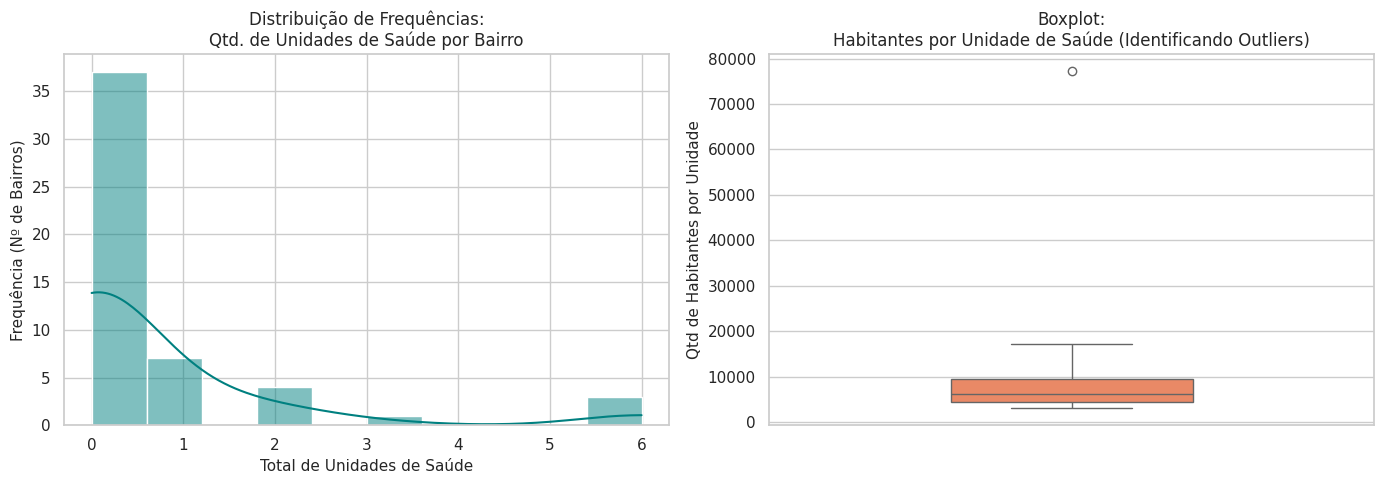

In [14]:
# ==============================================================================
# BLOCO 5: GRÁFICOS - HISTOGRAMA E BOXPLOT
# ==============================================================================

plt.figure(figsize=(14, 5))

# 1. Histograma (Distribuição de Frequências de Unidades de Saúde)
plt.subplot(1, 2, 1)
sns.histplot(df_final['Total_Unidades'], bins=10, kde=True, color='teal')
plt.title('Distribuição de Frequências:\nQtd. de Unidades de Saúde por Bairro', fontsize=12)
plt.xlabel('Total de Unidades de Saúde', fontsize=11)
plt.ylabel('Frequência (Nº de Bairros)', fontsize=11)

# 2. Boxplot (Identificando Visualmente os Outliers de Demanda)
plt.subplot(1, 2, 2)
# Usando os dados válidos para plotar a métrica de Habitantes/Unidade
sns.boxplot(y=df_validos['Hab_por_Unidade_Total'], color='coral', width=0.4)
plt.title('Boxplot:\nHabitantes por Unidade de Saúde (Identificando Outliers)', fontsize=12)
plt.ylabel('Qtd de Habitantes por Unidade', fontsize=11)

plt.tight_layout()
plt.show()

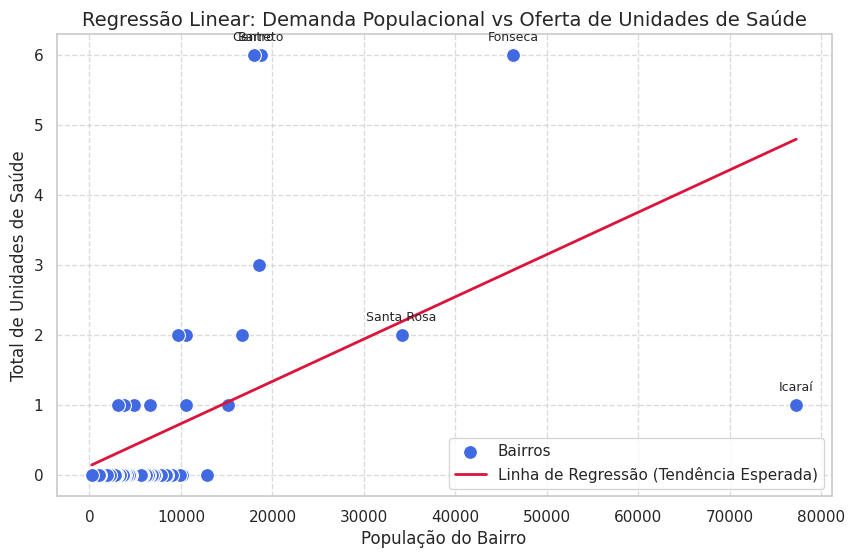


Coeficiente de Determinação (R²): 0.2537
Interpretação: Um R² próximo de 0 indica que o tamanho da população não está explicando a quantidade de unidades de saúde alocadas no bairro.


In [15]:
# ==============================================================================
# BLOCO 6: REGRESSÃO LINEAR - DEMANDA X OFERTA
# ==============================================================================

plt.figure(figsize=(10, 6))

# Limpar bairros que por acaso não tenham dado de população ou unidade para a regressão não falhar
df_reg = df_final.dropna(subset=['População', 'Total_Unidades']).copy()

# Preparar X (Variável Independente) e Y (Variável Dependente)
X = df_reg['População'].values.reshape(-1, 1)
y = df_reg['Total_Unidades'].values.reshape(-1, 1)

# Treinar o Modelo Linear
modelo = LinearRegression()
modelo.fit(X, y)
previsao = modelo.predict(X)

# Criar o Gráfico de Dispersão (Scatter)
sns.scatterplot(x='População', y='Total_Unidades', data=df_reg, s=100, color='royalblue', label='Bairros')

# Plotar a linha de Regressão
plt.plot(df_reg['População'], previsao, color='crimson', linewidth=2, label='Linha de Regressão (Tendência Esperada)')

# Anotar o nome de alguns bairros importantes no gráfico (bairros com muita gente ou muitas unidades)
for i, txt in enumerate(df_reg['NM_BAIRRO']):
    pop = df_reg['População'].iloc[i]
    uni = df_reg['Total_Unidades'].iloc[i]
    if uni > 4 or pop > 30000:
        plt.annotate(txt, (pop, uni), textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)

plt.title('Regressão Linear: Demanda Populacional vs Oferta de Unidades de Saúde', fontsize=14)
plt.xlabel('População do Bairro', fontsize=12)
plt.ylabel('Total de Unidades de Saúde', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Imprimir o R² (Coeficiente de Determinação)
r_quadrado = modelo.score(X, y)
print(f"\nCoeficiente de Determinação (R²): {r_quadrado:.4f}")
print("Interpretação: Um R² próximo de 0 indica que o tamanho da população não está explicando a quantidade de unidades de saúde alocadas no bairro.")

In [16]:
# ==============================================================================
# BLOCO 7 (EXTRA): VISUALIZAÇÃO ESPACIAL - MAPA DE HOSPITAIS EM NITERÓI
# ==============================================================================

# 1. Instalar a biblioteca de conversão de coordenadas
!pip install pyproj folium -q

import folium
from pyproj import Transformer
import pandas as pd

print("Gerando Mapa Interativo de Hospitais...")

# 2. Configurar o conversor de coordenadas atualizado (evita o aviso FutureWarning)
# Niterói (UTM 23S: epsg 31983) para Lat/Lon clássica (epsg 4326)
transformer = Transformer.from_crs("epsg:31983", "epsg:4326", always_xy=True)

df_mapa = df_hosp.dropna(subset=['X', 'Y', 'tx_nome', 'tx_bairro']).copy()

# 3. Função para converter as coordenadas
def converter_coordenadas(x, y):
    try:
        lon, lat = transformer.transform(x, y)
        return lat, lon
    except:
        return None, None

df_mapa['Lat'], df_mapa['Lon'] = zip(*df_mapa.apply(lambda row: converter_coordenadas(row['X'], row['Y']), axis=1))

# 4. Inicializar o Mapa
mapa_niteroi = folium.Map(location=[-22.883, -43.106], zoom_start=13, tiles='OpenStreetMap')

# 5. Adicionar os Hospitais
for idx, row in df_mapa.iterrows():
    if pd.isna(row['Lat']) or pd.isna(row['Lon']):
        continue

    popup_text = f"<b>{row['tx_nome']}</b><br>Bairro: {row['tx_bairro']}<br>Tipo: {row['Tipo_Unidade']}"
    cor_pino = 'red' if row['Tipo_Unidade'] == 'Pública' else 'blue'

    folium.Marker(
        location=[row['Lat'], row['Lon']],
        popup=folium.Popup(popup_text, max_width=300),
        icon=folium.Icon(color=cor_pino, icon='plus', prefix='fa')
    ).add_to(mapa_niteroi)

print("\nMapa gerado com sucesso! (Você pode dar zoom e clicar nos marcadores)")
mapa_niteroi

Gerando Mapa Interativo de Hospitais...

Mapa gerado com sucesso! (Você pode dar zoom e clicar nos marcadores)


In [17]:
# ==============================================================================
# BLOCO 7 (EXTRA/NOVO): MAPA COROPLÉTICO - ZONAS DE ASSISTÊNCIA EM NITERÓI
# ==============================================================================

# 1. Instalar as bibliotecas de geografia (geobr precisa do geopandas)
!pip install geobr geopandas folium -q

import folium
import geobr
import pandas as pd
import numpy as np

print("Baixando a malha geográfica de Niterói (IPEA)...")

try:
    # 2. Obtenção da Geografia oficial de Niterói (Ano 2022)
    malha_niteroi = geobr.read_neighborhood(year=2022)
    malha_niteroi = malha_niteroi[malha_niteroi['code_muni'] == 3303302.0].copy()

    # 3. Preparando os nossos DADOS REAIS para cruzar com o Mapa
    # Pegamos o df_final que criamos no Bloco 3
    dados_saude = df_final[['NM_BAIRRO', 'População', 'Pública', 'Privada', 'Hab_por_Unidade_Total']].copy()

    # Padronizar nomes para o Merge (remover acentos e colocar maiúsculo de ambos os lados)
    malha_niteroi['BAIRRO_MAPA'] = malha_niteroi['name_neighborhood'].apply(normalizar_bairro)
    dados_saude['BAIRRO_DADOS'] = dados_saude['NM_BAIRRO'].apply(normalizar_bairro)

    # Fazer o Merge Espacial
    mapa_completo = malha_niteroi.merge(dados_saude, left_on='BAIRRO_MAPA', right_on='BAIRRO_DADOS', how='left')

    # Preencher dados nulos para os bairros que existem no mapa mas não na nossa base
    mapa_completo['População'] = mapa_completo['População'].fillna(0)
    mapa_completo['Pública'] = mapa_completo['Pública'].fillna(0)
    mapa_completo['Privada'] = mapa_completo['Privada'].fillna(0)

    # 4. Função para Definir a Categoria e Cor (sua lógica perfeitamente aplicada)
    def definir_cor(row):
        sus = row['Pública']
        priv = row['Privada']

        if sus == 0 and priv == 0:
            return '#636e72', 'Deserto Assistencial'      # Cinza (Área Crítica)
        elif sus > 0 and priv == 0:
            return '#2ecc71', 'Apenas Pública (SUS)'      # Verde
        elif sus == 0 and priv > 0:
            return '#3498db', 'Apenas Privada'            # Azul (Ex: Icaraí)
        else:
            return '#9b59b6', 'Mista (Pública e Privada)' # Roxo (Melhor Cobertura)

    # Aplicando a lógica linha a linha
    mapa_completo[['cor', 'categoria']] = mapa_completo.apply(lambda row: pd.Series(definir_cor(row)), axis=1)

    # 5. Criação do Mapa Base (usando cartodbpositron para um visual mais limpo)
    m = folium.Map(location=[-22.90, -43.08], zoom_start=12, tiles='cartodbpositron')

    # 6. Adicionando a sua Legenda HTML (adaptada para as nossas cores e termos)
    legenda_html = '''
         <div style="position: fixed;
                     bottom: 50px; left: 50px; width: 230px; height: 130px;
                     background-color: white; border:2px solid grey; z-index:9999; font-size:12px;
                     padding: 10px; border-radius: 5px; box-shadow: 3px 3px 5px rgba(0,0,0,0.3);">
         <b>Zonas de Assistência de Saúde:</b><br><br>
         <i style="background:#636e72;width:14px;height:14px;display:inline-block;border-radius:50%;"></i> Deserto Assistencial<br>
         <i style="background:#2ecc71;width:14px;height:14px;display:inline-block;border-radius:50%;"></i> Apenas Pública (SUS)<br>
         <i style="background:#3498db;width:14px;height:14px;display:inline-block;border-radius:50%;"></i> Apenas Privada<br>
         <i style="background:#9b59b6;width:14px;height:14px;display:inline-block;border-radius:50%;"></i> Mista (Pública e Privada)
         </div>
         '''
    m.get_root().html.add_child(folium.Element(legenda_html))

    # 7. Adicionando as Zonas Coloridas ao Mapa
    folium.GeoJson(
        mapa_completo,
        style_function=lambda x: {
            'fillColor': x['properties']['cor'],
            'color': '#2c3e50', # Cor da borda do bairro
            'weight': 1,
            'fillOpacity': 0.75,
        },
        highlight_function=lambda x: {'weight': 3, 'fillOpacity': 0.9, 'color': 'black'},
        tooltip=folium.GeoJsonTooltip(
            fields=['name_neighborhood', 'População', 'categoria', 'Pública', 'Privada'],
            aliases=['Bairro:', 'População:', 'Status:', 'Unid. Públicas:', 'Unid. Privadas:'],
            localize=True, sticky=False, labels=True
        )
    ).add_to(m)

    print("\nMapa Coroplético gerado com sucesso! (Passe o mouse sobre os bairros)")
    display(m)

except Exception as e:
    print(f"❌ Erro na geração do mapa: {e}")

Baixando a malha geográfica de Niterói (IPEA)...

Mapa Coroplético gerado com sucesso! (Passe o mouse sobre os bairros)


In [28]:
# ==============================================================================
# BLOCO DE EXTRAÇÃO (HISTÓRICO): DATASUS E CRIAÇÃO DO CSV
# OBSERVAÇÃO: Este bloco foi executado apenas uma vez na fase de Engenharia
# de Dados (ETL) para gerar o arquivo CSV. Não é necessário rodar novamente.
# ==============================================================================

# 1. Instalação das bibliotecas
!pip install git+https://github.com/AlertaDengue/PySUS.git --upgrade -q
!pip install tqdm>=4.66.3 python-dateutil>=2.9.0 -q

import pandas as pd
from pysus.online_data import CNES

print("Iniciando conexão com o DataSUS...")

try:
    # 2. Extração de Dados (Leitos LT - RJ). Usando o último ano consolidado.
    dataset = CNES.download(group='LT', states=['RJ'], years=[2023], months=[12])
    df_rj = dataset.to_dataframe()

    # 3. Filtro para Niterói (Código IBGE 330330)
    df_niteroi_leitos = df_rj[df_rj['CODUFMUN'].astype(str).str.contains('330330')].copy()

    # 4. SALVANDO EM CSV NO GOOGLE DRIVE
    caminho_salvar = '/content/drive/MyDrive/DATA/CNES_Leitos_Niteroi.csv'
    df_niteroi_leitos.to_csv(caminho_salvar, index=False, encoding='utf-8')

    print(f"✅ Sucesso! {len(df_niteroi_leitos)} registros de leitos baixados.")
    print(f"💾 Arquivo salvo permanentemente em: {caminho_salvar}")

except Exception as e:
    print(f"❌ Erro detectado: {e}")

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 6.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 6.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.7/118.7 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 247.7/247.7 kB 25.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.5/63.5 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.4/300.4 kB 28.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 88.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.3/58.3

LTRJ2312.parquet: 100%|██████████| 2.20k/2.20k [00:00<00:00, 5.95kB/s]


✅ Sucesso! 196 registros de leitos baixados.
💾 Arquivo salvo permanentemente em: /content/drive/MyDrive/DATA/CNES_Leitos_Niteroi.csv


--- RAIO-X DA CAPACIDADE HOSPITALAR DE NITERÓI ---
População Total analisada: 481.749
Total de Leitos (Públicos / SUS): 1.122
Total de Leitos (Privados / Não-SUS): 2.014
Total Geral de Leitos na cidade: 3.136

➔ INDICADOR OMS: 6.51 leitos para cada 1.000 habitantes.
   Status: DENTRO da meta recomendada pela Organização Mundial da Saúde (3 a 5)


/tmp/ipykernel_7686/4180627737.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Públicos (SUS)', 'Privados (Não-SUS)'],


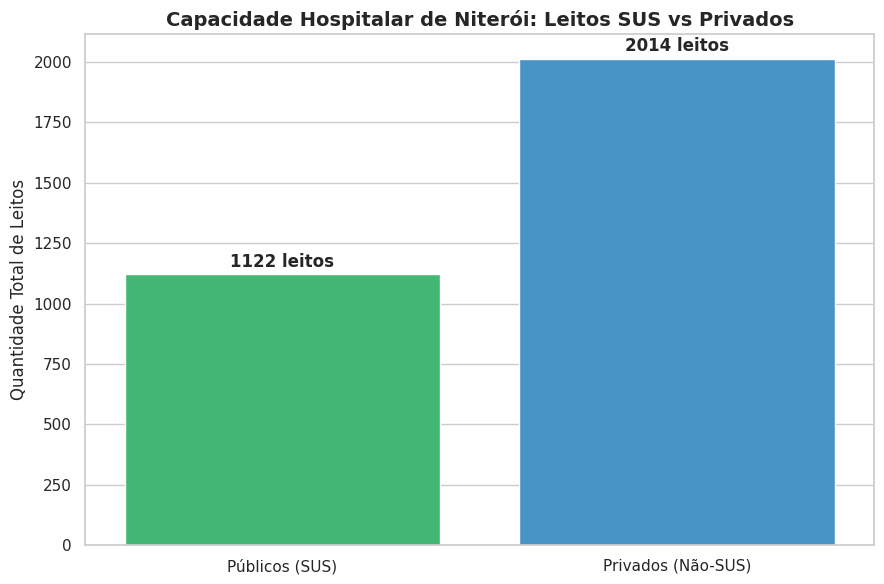

In [31]:
# ==============================================================================
# BLOCO 8: ANÁLISE DE CAPACIDADE HOSPITALAR E INDICADOR DA OMS
# ==============================================================================

print("--- RAIO-X DA CAPACIDADE HOSPITALAR DE NITERÓI ---")

# 1. Tratamento dos dados de Leitos (já carregados no Bloco 1 como df_leitos)
# Garantindo que as colunas sejam números para podermos somar
df_leitos['QT_SUS'] = pd.to_numeric(df_leitos['QT_SUS'], errors='coerce').fillna(0)
df_leitos['QT_NSUS'] = pd.to_numeric(df_leitos['QT_NSUS'], errors='coerce').fillna(0)

# 2. Cálculos Totais de Niterói
total_sus = df_leitos['QT_SUS'].sum()
total_privado = df_leitos['QT_NSUS'].sum()
total_leitos = total_sus + total_privado

# 3. Cálculo da Métrica Ouro (Recomendação OMS: 3 a 5 leitos por mil habitantes)
# Pegamos a população total que já calculamos no Bloco 3 (df_niteroi)
populacao_total = df_niteroi['População'].sum()
taxa_oms = (total_leitos / populacao_total) * 1000

print(f"População Total analisada: {int(populacao_total):,}".replace(',', '.'))
print(f"Total de Leitos (Públicos / SUS): {int(total_sus):,}".replace(',', '.'))
print(f"Total de Leitos (Privados / Não-SUS): {int(total_privado):,}".replace(',', '.'))
print(f"Total Geral de Leitos na cidade: {int(total_leitos):,}".replace(',', '.'))

print(f"\n➔ INDICADOR OMS: {taxa_oms:.2f} leitos para cada 1.000 habitantes.")
if taxa_oms >= 3:
    print("   Status: DENTRO da meta recomendada pela Organização Mundial da Saúde (3 a 5)")
else:
    print("   Status: ABAIXO da meta recomendada pela Organização Mundial da Saúde (3 a 5)")

# 4. Visualização Gráfica
plt.figure(figsize=(9, 6))
sns.barplot(x=['Públicos (SUS)', 'Privados (Não-SUS)'],
            y=[total_sus, total_privado],
            palette=['#2ecc71', '#3498db'])

plt.title('Capacidade Hospitalar de Niterói: Leitos SUS vs Privados', fontsize=14, fontweight='bold')
plt.ylabel('Quantidade Total de Leitos', fontsize=12)

# Adicionando os números exatos em cima de cada barra para ficar mais fácil de ler
for i, valor in enumerate([total_sus, total_privado]):
    plt.text(i, valor + 30, f'{int(valor)} leitos', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()